(34451, 16)
url                              0
address                          0
name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
phone                          473
location                         0
rest_type                      127
cuisines                         0
approx_cost(for two people)      0
reviews_list                     0
menu_item                        0
listed_in(type)                  0
listed_in(city)                  0
dtype: int64
url                             object
address                         object
name                            object
online_order                    object
book_table                      object
rate                           float64
votes                            int64
phone                           object
location                        object
rest_type                       object
cuisines                 

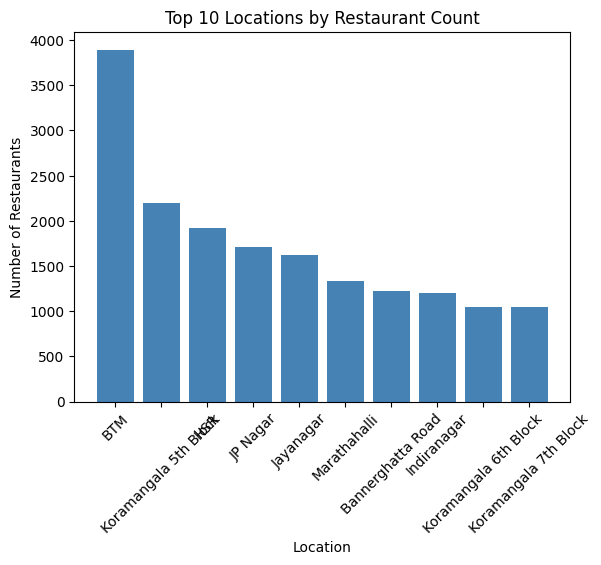

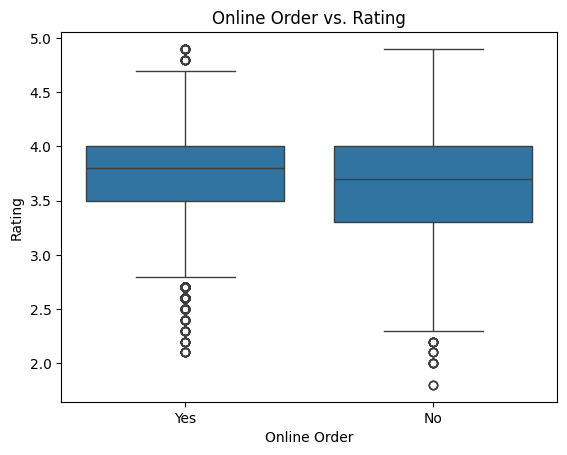

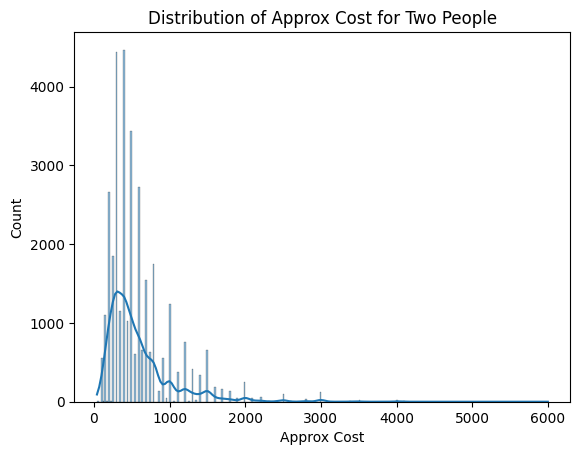

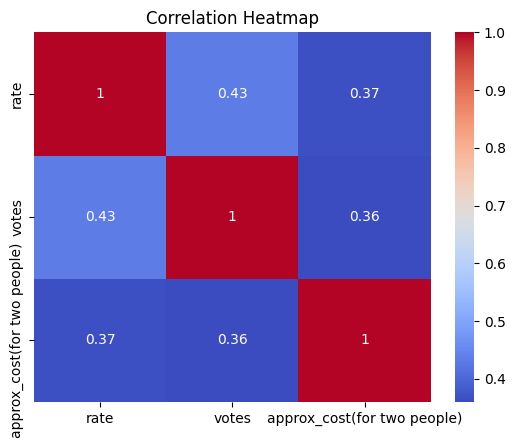

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('/content/zomato.csv',
                 encoding='latin-1',
                 on_bad_lines='skip',
                 engine='python')

# Clean
df.drop_duplicates(inplace=True)
df.drop(columns=['dish_liked'], inplace=True)
df['rate'] = df['rate'].str.replace('/5', '').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df.dropna(subset=['rate'], inplace=True)
df.dropna(subset=['approx_cost(for two people)'], inplace=True)
df.dropna(subset=['location'], inplace=True)
df.dropna(subset=['cuisines'], inplace=True)

# Verify
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
df['location'].value_counts().head(10)
df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10)
df.groupby('online_order')['rate'].mean()
df.groupby('location')['approx_cost(for two people)'].mean().sort_values(ascending=False).head(10)

top_locations = df['location'].value_counts().head(10)
plt.bar(top_locations.index, top_locations.values, color='steelblue')
plt.title('Top 10 Locations by Restaurant Count')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)   # rotate x labels so they don't overlap
plt.show()

sns.boxplot(data=df, x='online_order' , y='rate')
plt.title('Online Order vs. Rating')
plt.xlabel('Online Order')
plt.ylabel('Rating')
plt.show()

sns.histplot(data=df, x='approx_cost(for two people)', kde=True)
plt.title('Distribution of Approx Cost for Two People')
plt.xlabel('Approx Cost')
plt.show()

# Calculate the correlation matrix for the desired numeric columns
correlation_matrix = df[['rate', 'votes', 'approx_cost(for two people)']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()